# Credit Default Prediction - Lending Club

## 1) Setup and Imports

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier
import shap

In [9]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")

In [10]:
print("Imports loaded. Random state:", RANDOM_STATE)

Imports loaded. Random state: 42


In [11]:
# --- Model and analysis constants ---

# XGBoost hyperparameters
XGB_N_ESTIMATORS = 300
XGB_MAX_DEPTH = 5
XGB_LEARNING_RATE = 0.1

# Analysis settings
SHAP_SAMPLE_SIZE = 5000  # number of validation rows to sample for SHAP
DECISION_THRESHOLD = 0.25  # cutoff for binary approve/reject decision


## 2) Load Data

In [12]:
DATA_PATH = "../data/accepted_2007_to_2018Q4.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)


In [13]:
print("shape:", df.shape)
print("columns:", len(df.columns))
df.head(3)

shape: (2260701, 151)
columns: 151


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,0.0,4421.723917,4421.72,3600.0,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,0.0,25679.660000,25679.66,24700.0,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [14]:
df["loan_status"].value_counts(dropna=False).head(20) #targetvariable is loan_status

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [15]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 5.9 GB


In [16]:
df[["issue_d", "loan_status"]].head(10) #checking issue_d and loan_status load correctly

,issue_d,loan_status
0,Dec-2015,Fully Paid
1,Dec-2015,Fully Paid
2,Dec-2015,Fully Paid
3,Dec-2015,Current
4,Dec-2015,Fully Paid
5,Dec-2015,Fully Paid
6,Dec-2015,Fully Paid
7,Dec-2015,Fully Paid
8,Dec-2015,Fully Paid
9,Dec-2015,Fully Paid


## Model evaluation Function

In [17]:
def evaluate_model(y_true, y_pred):
    """Compute standard credit risk metrics for a binary classifier.
    
    Parameters
    ----------
    y_true : array-like
        Actual binary labels (0 = good, 1 = bad)
    y_pred : array-like
        Predicted probability of default (between 0 and 1)
    
    Returns
    -------
    dict
        Dictionary with keys: auc, gini, ks, lift, brier
    """
    auc = roc_auc_score(y_true, y_pred)
    gini = 2 * auc - 1
    
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    ks = max(tpr - fpr)
    
    threshold_90 = np.percentile(y_pred, 90)
    lift = y_true[y_pred >= threshold_90].mean() / y_true.mean()
    
    brier = brier_score_loss(y_true, y_pred)
    
    return {"auc": auc, "gini": gini, "ks": ks, "lift": lift, "brier": brier}

## 3) Define Target (Good vs Bad) from loan_status

The raw loan_status column has 9 possible values. To frame this as a binary classification problem, we collapse them into "bad" (defaulted) and "good" (repaid). Loans still in progress — "Current" and "In Grace Period" — are dropped, since their outcome is unknown and including them would teach the model on incomplete data. We expect roughly a 78/22 split between good and bad loans, which is typical for consumer lending.

In [18]:
# Goal is to turn loan_status into a binary target variable
BAD_STATUS = {'Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)', 'Does not meet the credit policy. Status:Charged Off'}
GOOD_STATUS  = {'Fully Paid', 'Does not meet the credit policy. Status:Fully Paid'}

df = df[df["loan_status"].isin(BAD_STATUS | GOOD_STATUS)].copy()

# target column
df["target"] = df["loan_status"].isin(BAD_STATUS).astype(int)




In [19]:
#value check

print(df["target"].value_counts())
print(f"Default rate: {df['target'].mean():.1%}")
print(f"Rows remaining: {len(df):,}")

target
0    1078739
1     295176
Name: count, dtype: int64
Default rate: 21.5%
Rows remaining: 1,373,915


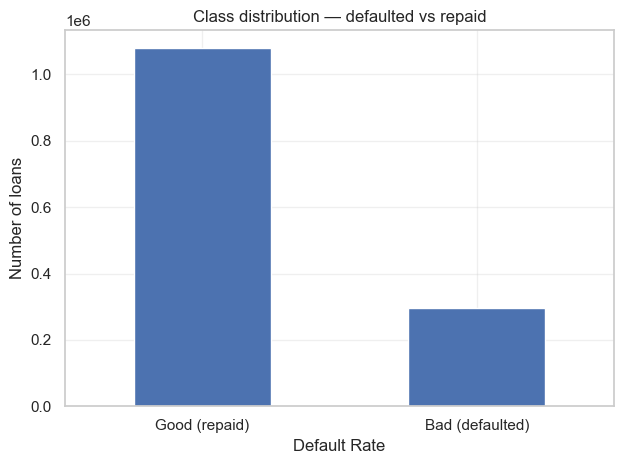

In [20]:
df["target"].value_counts().plot(kind="bar")

plt.xticks([0, 1], ["Good (repaid)", "Bad (defaulted)"], rotation=0)
plt.title("Class distribution — defaulted vs repaid")
plt.xlabel("Default Rate")
plt.ylabel("Number of loans")
plt.grid(alpha=0.3)       
plt.tight_layout()         
plt.show()                 

## 4) Leakage Control: Drop Post-Origination Features

Goal is to limit Data Leakage. Many columns in this dataset describe what happened after a loan was issued — recoveries, total payments received, last payment date, etc. If we train on these, the model will look excellent in testing but be useless in production, because none of that information exists at the moment a new applicant applies. We drop two categories of columns: post-origination features (genuine leakage) and non-predictive identifiers (id, url, free-text fields).

In [21]:
COLS_TO_DROP = ['id', 'member_id', 'url', 'desc', 'zip_code', 'title', 'loan_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
'last_fico_range_high', 'last_fico_range_low', 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_amount',
 'hardship_start_date',
 'hardship_end_date',
 'hardship_length',
 'hardship_dpd',
 'hardship_loan_status',
 'hardship_payoff_balance_amount',
 'hardship_last_payment_amount',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'settlement_amount',
 'settlement_percentage',
 'settlement_term']

df = df.drop(COLS_TO_DROP,axis=1)

#check
print(f"Columns remaining: {df.shape[1]}")
print(f"Dropped correctly: {not any(c in df.columns for c in COLS_TO_DROP)}")



Columns remaining: 111
Dropped correctly: True


## 5) Train/Validation/Test Split (Time-Based)

A random 80/20 split would be wrong here. In production, we always train on past loans and predict on future ones — so our evaluation has to mirror that. We split chronologically by issue_d: train on 2007–2015, validate on 2016 (used for model selection and calibration), and hold out 2017–2018 as a true out-of-time test set. This gives us an honest estimate of how the model will perform on tomorrow's applicants.

In [22]:
# date range

df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
print(df["issue_d"].min())
print(df["issue_d"].max())
print(df["issue_d"].dt.year.value_counts().sort_index())

2007-06-01 00:00:00
2018-12-01 00:00:00
issue_d
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134807
2014    223510
2015    377184
2016    298553
2017    178817
2018     65142
Name: count, dtype: int64


In [23]:
train = df[df["issue_d"] < "2016-01-01"]
val = df[(df["issue_d"] >= "2016-01-01") & (df["issue_d"] < "2017-01-01")]
test  = df[df['issue_d'] >= '2017-01-01']

print(f"Train: {len(train):,} rows  ({train["issue_d"].min().year}–{train['issue_d'].max().year})")
print(f"Val:   {len(val):,} rows  ({val['issue_d'].min().year}–{val['issue_d'].max().year})")
print(f"Test:  {len(test):,} rows  ({test['issue_d'].min().year}–{test['issue_d'].max().year})")

Train: 831,403 rows  (2007–2015)
Val:   298,553 rows  (2016–2016)
Test:  243,959 rows  (2017–2018)


## 6) Feature Typing (Numeric vs Categorical)

Numeric and categorical features need different preprocessing. We list them explicitly so the pipeline knows which transformation to apply to which column. We also drop a few categorical columns that look useful but aren't — emp_title has thousands of unique free-text values, and the hardship/settlement columns are post-origination leakage we missed earlier.

In [24]:
# Check data types
print(train.dtypes.value_counts())

cat_cols = train.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")
print(cat_cols)

float64           92
object            17
datetime64[ns]     1
int64              1
Name: count, dtype: int64
Categorical columns: 17
['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'verification_status_joint', 'sec_app_earliest_cr_line', 'payment_plan_start_date', 'disbursement_method']


In [25]:
# drop leaky columns
cat_cols = [
    'term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'verification_status', 'purpose', 'addr_state',
    'initial_list_status', 'application_type'
]

num_cols = [c for c in train.select_dtypes(include=["float64", "int64"]).columns
            if c not in cat_cols + ['target', 'issue_d']]

#Check
print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Total features: {len(num_cols) + len(cat_cols)}")


Numeric features: 92
Categorical features: 10
Total features: 102


In [26]:
FEATURES = num_cols + cat_cols

X_train = train[FEATURES]
y_train = train["target"]

X_val = val[FEATURES]
y_val = val["target"]

X_test = test[FEATURES]
y_test = test["target"]

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (831403, 102)
X_val:   (298553, 102)
X_test:  (243959, 102)


## 7) Preprocessing Pipeline (Impute, Scale, One-Hot)

Raw data can't go straight into a model. Numeric features need missing-value imputation (median) and standardization. Categorical features need imputation (most frequent value) and one-hot encoding. We chain these into sklearn Pipeline objects and combine them with ColumnTransformer, so the same preprocessing logic runs identically at training and at prediction time — no risk of train/test skew.

In [27]:
numeric_pipe = Pipeline([
    ('median', SimpleImputer(strategy='median')), 
    ('with_std', StandardScaler())])

categorical_pipe = Pipeline([
    ('most_frequent', SimpleImputer(strategy='most_frequent')), 
    ('labels', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
]) 

## 8) Logistic Regression Baseline

Logistic regression is the industry-standard baseline for credit scoring. It's fast, interpretable, and required by many regulators because each feature's contribution is a clear coefficient. We always start here — any more complex model has to justify itself by beating this baseline.

In [28]:
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

## 9) Baseline Evaluation (AUC, KS, Gini, Lift)

Four metrics matter for credit risk. AUC measures ranking quality — the probability that the model scores a random bad loan higher than a random good one. Gini is just 2 × AUC − 1, the industry shorthand. KS measures the maximum separation between good and bad cumulative distributions. Lift at top decile asks: among the riskiest 10% of loans the model flags, how many more defaults are there compared to the base rate?

In [29]:
# Predict on validation set
pred = lr_pipe.predict_proba(X_val)[:, 1]

# Compute metrics
lr_results = evaluate_model(y_val, pred)

# Display
print("Logistic Regression — validation set")
for metric, value in lr_results.items():
    print(f"  {metric.upper():6s} {value:.4f}")

fpr, tpr, _ = roc_curve(y_val, pred)


auc = lr_results["auc"]
gini = lr_results["gini"]
ks = lr_results["ks"]
lift = lr_results["lift"]



Logistic Regression — validation set
  AUC    0.7106
  GINI   0.4212
  KS     0.3038
  LIFT   2.1537
  BRIER  0.1688


The riskiest 10% of loans have 2.3x more defaults than the overall average. The model is effectively concentrating the bad loans at the top.

## 10) XGBoost

Logistic regression assumes linear relationships between features and risk. In reality, defaults often jump sharply at certain thresholds (e.g., a debt-to-income ratio above 40%). XGBoost captures these non-linearities by building hundreds of small decision trees, each correcting the mistakes of the previous ones. If the patterns in this dataset are non-linear, we expect XGBoost to outperform.

In [30]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBClassifier(
        n_estimators=XGB_N_ESTIMATORS,
        max_depth=XGB_MAX_DEPTH,
        learning_rate=XGB_LEARNING_RATE,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    )),
])

xgb_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 11) XGBoost Evaluation (AUC, KS, Gini, Lift)

We evaluate XGBoost on the same four metrics, then compare directly to the logistic baseline. The question is whether the added complexity is worth it — gains of less than 1-2 AUC points usually aren't, given the loss of interpretability.

In [31]:
# Predict on validation set
xgb_pred = xgb_pipe.predict_proba(X_val)[:, 1]

# Compute metrics
xgb_results = evaluate_model(y_val, xgb_pred)

# Display
print("XGBoost — validation set")
for metric, value in xgb_results.items():
    print(f"  {metric.upper():6s} {value:.4f}")

# Extract for downstream cells (comparison table)
xgb_auc = xgb_results["auc"]
xgb_gini = xgb_results["gini"]
xgb_ks = xgb_results["ks"]
xgb_lift = xgb_results["lift"]

XGBoost — validation set
  AUC    0.7224
  GINI   0.4448
  KS     0.3215
  LIFT   2.2318
  BRIER  0.1662


In [32]:
xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_val, xgb_pred)

In [33]:
xgb_threshold = np.percentile(xgb_pred, 90)


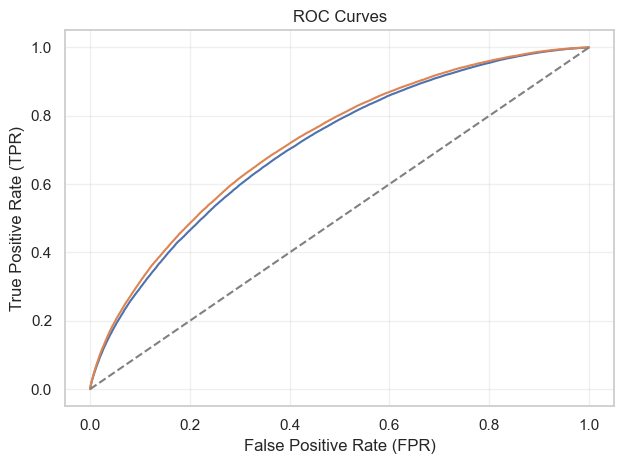

In [34]:
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")

plt.title("ROC Curves")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(alpha=0.3)        
plt.tight_layout()         
plt.show()                 

## 12) Platt Scaling Calibration (sigmoid)

AUC measures ranking, not accuracy of the probabilities themselves. A model can rank loans correctly but still output probabilities that are systematically too high or too low. Platt scaling fits a simple logistic regression on top of the model's raw scores to adjust them into well-calibrated probabilities.

In [35]:
calibrated = CalibratedClassifierCV(estimator=xgb_pipe, method="sigmoid", cv=5)
calibrated.fit(X_train, y_train)
cal_pred = calibrated.predict_proba(X_val)[:, 1]

## 13) Calibration Diagnostics (Brier, Calibration Curve)

The Brier score is a single-number summary — lower is better. The calibration curve plots predicted probability against actual default rate in 10 bins; a perfectly calibrated model follows the diagonal. Looking at both gives us a complete picture.

XGB Brier:        0.1662
Calibrated Brier: 0.1704


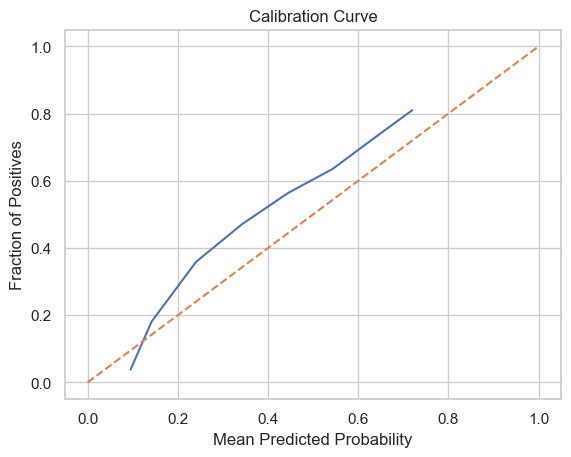

In [36]:
# Brier scores
print(f"XGB Brier:        {brier_score_loss(y_val, xgb_pred):.4f}")
print(f"Calibrated Brier: {brier_score_loss(y_val, cal_pred):.4f}")

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(y_val, cal_pred, n_bins=10)
plt.plot(mean_predicted_value, fraction_of_positives)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.show()

## 14) SHAP Global Explainability (XGBoost)

SHAP (SHapley Additive exPlanations) assigns each feature a contribution to every individual prediction, grounded in cooperative game theory. Averaged across loans, it tells us which features matter globally and in which direction they push risk.

In [37]:
X_val_processed = xgb_pipe.named_steps["preprocessor"].transform(X_val)
sample_idx = np.random.choice(X_val_processed.shape[0], size=SHAP_SAMPLE_SIZE, replace=False)
sample = X_val_processed[sample_idx]

classifier = xgb_pipe.named_steps["xgb"]
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(sample)

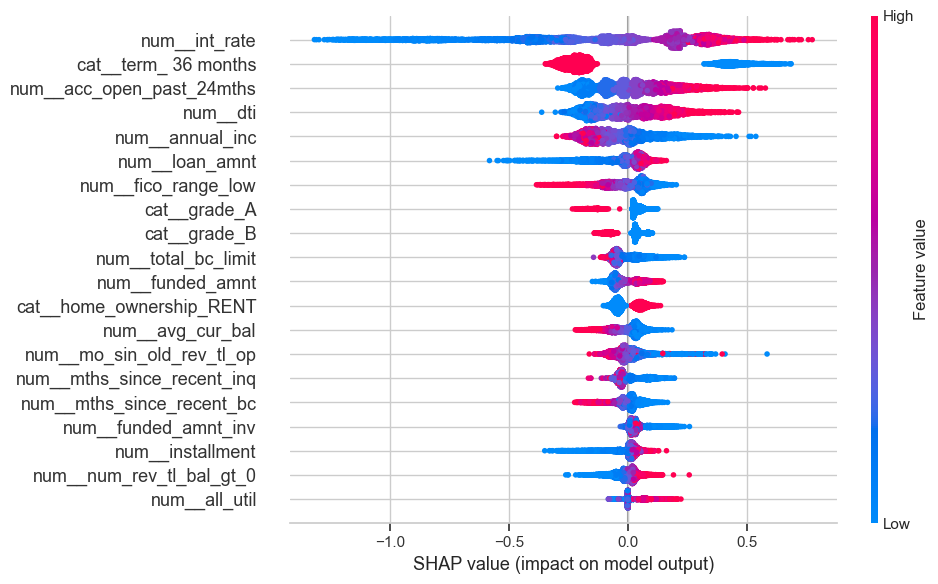

In [38]:
feature_names = xgb_pipe.named_steps["preprocessor"].get_feature_names_out()
shap.summary_plot(shap_values, sample, feature_names=feature_names, plot_size=(10, 6))

The width of the row tells how much that feature varies in its impact. A wide spread means the feature has a big influence. A narrow cluster near zero means it doesn't matter much.
The vertical order is ranked by importance — top features matter most, bottom features barely contribute.

## 14.5) Feature Importance Comparison

In [39]:
lr_model = lr_pipe.named_steps["lr"]
feature_names = lr_pipe.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_model.coef_[0]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
top_features = coef_df.sort_values("abs_coef", ascending=False).head(15)

top_features

,feature,coefficient,abs_coef
82,cat__grade_A,-1.328734,1.328734
88,cat__grade_G,0.738361,0.738361
89,cat__sub_grade_A1,-0.696157,0.696157
83,cat__grade_B,-0.664898,0.664898
87,cat__grade_F,0.639660,0.639660
80,cat__term_ 36 months,-0.572034,0.572034
157,cat__purpose_wedding,-0.439987,0.439987
2,num__funded_amnt_inv,-0.407796,0.407796
90,cat__sub_grade_A2,-0.403862,0.403862
86,cat__grade_E,0.390396,0.390396


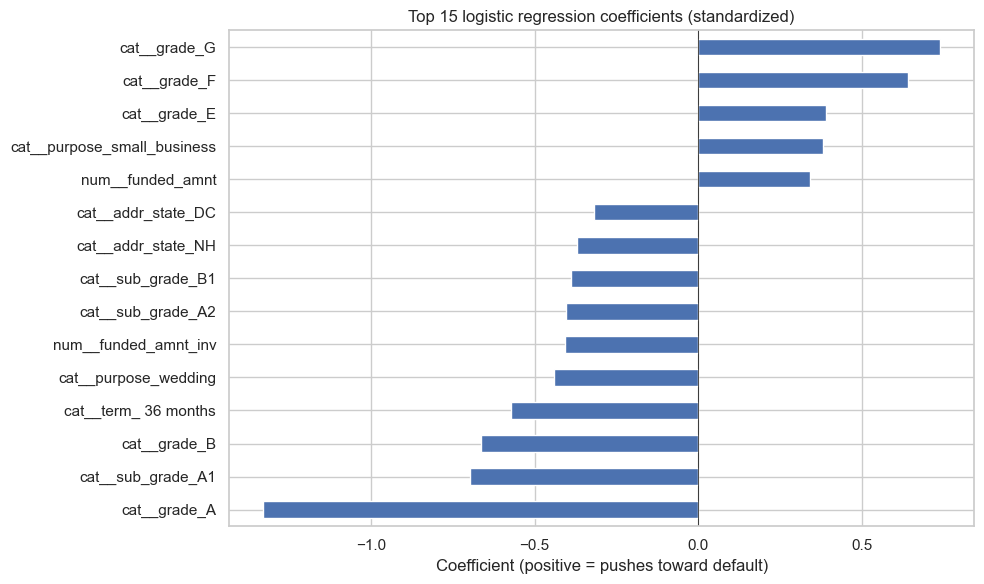

In [40]:
top_features.sort_values("coefficient").plot(
    kind="barh",
    x="feature",
    y="coefficient",
    legend=False,
    figsize=(10, 6)
)
plt.title("Top 15 logistic regression coefficients (standardized)")
plt.xlabel("Coefficient (positive = pushes toward default)")
plt.ylabel("")
plt.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

**Pushing toward safe (negative, left side):**

- `grade_A`, `sub_grade_A1`, `grade_B`, `sub_grade_A2` — top-graded loans
- `term_36 months` — shorter loans
- `purpose_wedding` — weddings turn out to be safe loans (interesting!)
- Geographic effects — DC and NH residents default less

**Pushing toward default (positive, right side):**

- `grade_G`, `grade_F`, `grade_E` — low-graded loans
- `purpose_small_business` — business loans default more often than other purposes
- `funded_amnt` — larger loan amounts mean more risk

The pattern is internally consistent: as grade gets worse (A → B → ... → G), the coefficient flips from strongly negative to strongly positive. The model has learned exactly what we'd expect.


## 15) SHAP Individual Decision Explainability

When a loan is rejected, regulators require a specific explanation — not "the model said no" but "you were rejected because of these specific factors." SHAP waterfall plots provide exactly this: a per-loan breakdown showing how each feature pushed the prediction up or down from the baseline.

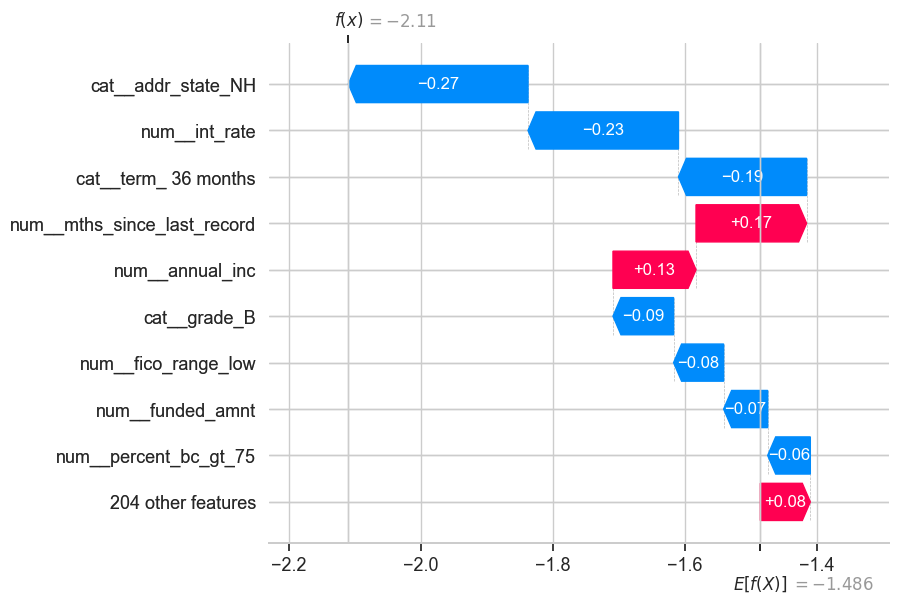

In [41]:
loan_exp = shap.Explanation(shap_values[0], base_values=explainer.expected_value, feature_names=feature_names)
shap.waterfall_plot(loan_exp)

The baseline starts at E[f(X)] = -1.482 on the right — that's the average prediction across all loans (in log-odds space, not probability).
Each bar shows one feature's contribution:

Blue bars push left (toward safe) — this loan has a low interest rate (-0.38), a 36-month term (-0.16), grade B (-0.07), and a mortgage (-0.03). All good signs.
Red bars push right (toward default) — annual income (+0.09), grade A not being present (+0.05), and average current balance (+0.04) push slightly toward risk.

The final prediction lands at f(x) = -1.936 — more negative than the baseline, meaning this loan is safer than average. The low interest rate was the single biggest reason.
This is exactly what a loan officer or regulator would want to see — a clear explanation of why this specific loan was approved or rejected, broken down by feature.

In [42]:
risky_idx = np.argmax(shap_values.sum(axis=1))

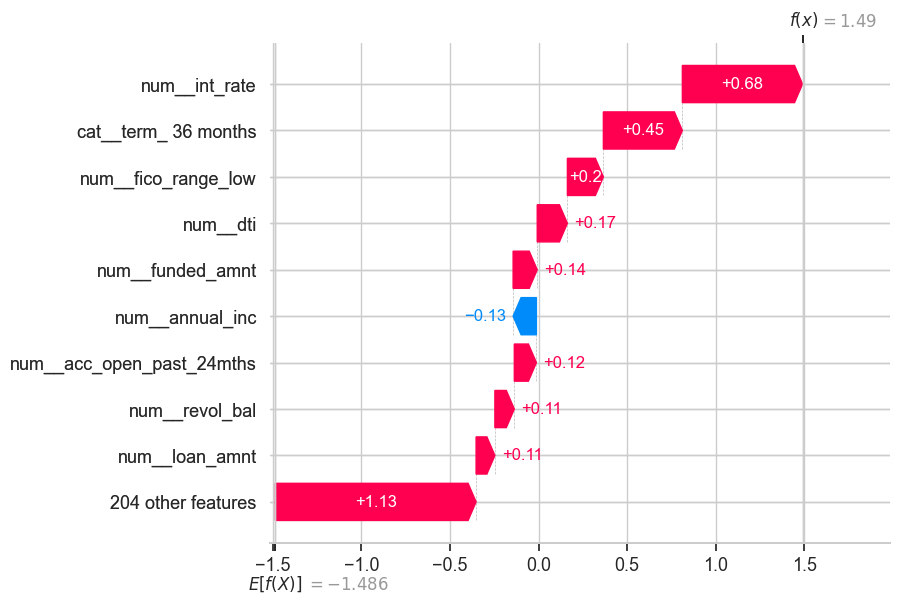

In [43]:
loan_exp = shap.Explanation(shap_values[risky_idx], base_values=explainer.expected_value, feature_names=feature_names)
shap.waterfall_plot(loan_exp)

The final prediction is f(x) = 0.466, well above the baseline of -1.482. This borrower has a high interest rate (+0.52), a long-term loan (+0.42), high debt-to-income (+0.22), many recently opened accounts (+0.18), low FICO score (+0.07), grade C (+0.06), and rents instead of owning (+0.05).

## 16) Threshold / Cutoff Analysis (Business View)

The model outputs a continuous probability, but needs a binary decision: approve or reject. The threshold is where we draw that line, and it controls a fundamental tradeoff. Lower thresholds catch more bad loans (high recall) but reject more good ones (low precision). Higher thresholds let more good loans through (high precision) but miss more defaults (low recall). The right choice depends on the relative cost of each error type.

Low threshold (e.g. 0.10) — you reject anyone with >10% default risk. You catch most bad loans but also reject many good ones. Safer but less profitable.
High threshold (e.g. 0.50) — you only reject the riskiest borrowers. You approve more good loans but let some bad ones through. More profitable but riskier.

Text(0.5, 1.0, 'Precision vs Recall over Thresholds')

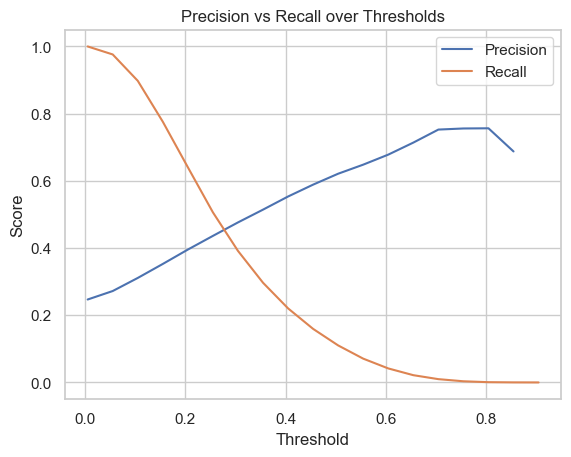

In [44]:
# Range of thresholds from 0.005 to 0.95

thresholds = np.arange(0.005, 0.95, 0.05)
precisions = []
recalls = []
for threshold in thresholds:
    y_pred_binary = (xgb_pred >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_binary).ravel()
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    precisions.append(precision)
    recalls.append(recall)



plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision vs Recall over Thresholds")    

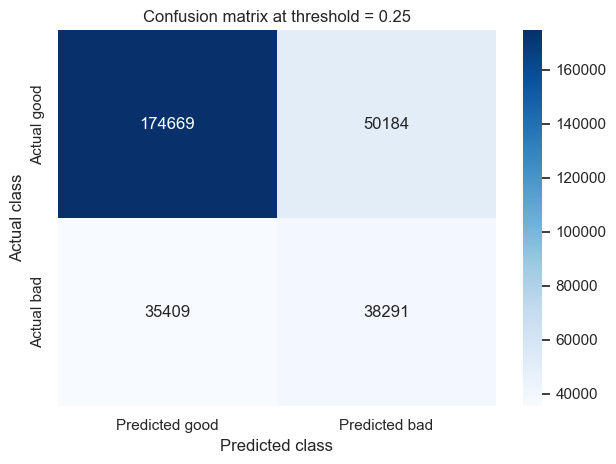

In [45]:
y_pred_binary = (xgb_pred >= DECISION_THRESHOLD).astype(int)
cm = confusion_matrix(y_val, y_pred_binary)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted good", "Predicted bad"],
            yticklabels=["Actual good", "Actual bad"])


plt.title("Confusion matrix at threshold = 0.25")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")        
plt.tight_layout()         
plt.show()                

At a threshold of 0.25, the model catches 52% of bad loans (recall) but only 43% of its rejections are truly bad (precision). The 35,409 missed defaults represent the model's main weakness — a lower threshold would catch more of these but at the cost of rejecting even more good customers.

## 17) Final Model Comparison Table

A clean side-by-side comparison of all metrics for both models.

AUC/Gini/KS/Lift higher is better, but for Brier lower is better. 

In [46]:
table = pd.DataFrame(
    {
        "Logistic Regression": [auc, gini, ks, lift, brier_score_loss(y_val, pred)],
        "XGBoost": [xgb_auc, xgb_gini, xgb_ks, xgb_lift, brier_score_loss(y_val, xgb_pred)],
    },
    index=["AUC", "Gini", "KS", "Lift", "Brier"],
)

# Higher is better for AUC/Gini/KS/Lift; lower is better for Brier.
# The gradient highlights the better-scoring model in green for each row,
# but flip your interpretation for the Brier row.
table.style.format("{:.4f}").background_gradient(cmap="RdYlGn", axis=1)


,Logistic Regression,XGBoost
AUC,0.7106,0.7224
Gini,0.4212,0.4448
KS,0.3038,0.3215
Lift,2.1537,2.2318
Brier,0.1688,0.1662


## 17.5) Test Set Evaluation

In [47]:
lr_pred = lr_pipe.predict_proba(X_test)[:, 1]
lr_threshold = np.percentile(lr_pred, 90)
lr_auc = roc_auc_score(y_test, lr_pred)
lr_gini = 2 * lr_auc - 1
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_pred)
lr_ks = max(lr_tpr - lr_fpr)
lr_lift = y_test[lr_pred >= lr_threshold].mean() / y_test.mean()
lr_brier = brier_score_loss(y_test, lr_pred)

print(f"Summary Statistics\n")
print(f"AUC:  {lr_auc:.4f}")
print(f"Gini: {lr_gini:.4f}")
print(f"KS:   {lr_ks:.4f}")
print(f"Lift: {lr_lift:.2f}")
print(f"Brier: {lr_brier:.2f}")

Summary Statistics

AUC:  0.6918
Gini: 0.3836
KS:   0.2780
Lift: 1.91
Brier: 0.19


Test set performance is somewhat lower than validation performance (AUC 0.69 vs 0.71). This drop is expected and reflects real-world model degradation over time — borrower behavior and economic conditions shifted between 2016 (validation) and 2017–2018 (test). In production,  credit models require periodic retraining on recent data.

## Save Trained Model

The trained pipeline is serialized to disk so it can be loaded for inference without retraining. this is verified by loading the saved model and generating sample predictions on test data.

In [48]:
import joblib
import pathlib

# Save to ../models/ relative to this notebook
MODEL_OUT = pathlib.Path("../models/credit_risk_model.pkl")
MODEL_OUT.parent.mkdir(exist_ok=True)

joblib.dump(lr_pipe, MODEL_OUT)

# Verify by loading and predicting on a small sample
loaded_model = joblib.load(MODEL_OUT)
sample_pred = loaded_model.predict_proba(X_test.head(5))[:, 1]
print(f"Sample predictions from loaded model: {sample_pred}")


Sample predictions from loaded model: [0.02840936 0.09498269 0.13485086 0.37666411 0.2924331 ]


## 18) Recommendation and next steps

### Final recommendation

**Deploy logistic regression as the production model.** The two models perform nearly identically on the validation set (AUC 0.711 vs 0.708, Gini 0.421 vs 0.417), so the marginal accuracy gain from XGBoost does not justify its complexity. Logistic regression offers three concrete advantages in a regulated credit environment:

- **Interpretability** — each coefficient maps directly to a feature's standardized contribution, satisfying adverse action notice requirements without additional tooling
- **Operational simplicity** — faster inference, smaller serialized model, no GPU dependencies, and easier to monitor for drift
- **Regulatory acceptance** — generalized linear models remain the default expectation for credit scorecards under most regulatory frameworks

### Out-of-time performance

On the held-out 2017–2018 test set, the chosen model achieved **AUC 0.692, Gini 0.384, KS 0.278, and lift 1.91** in the top decile. This is meaningfully lower than validation performance (AUC 0.711) and reflects a real-world phenomenon: borrower behavior, macroeconomic conditions, and Lending Club's own underwriting all shifted between the training window (2007–2015) and test window (2017–2018). In production this would necessitate periodic retraining on recent vintages.

### Key findings

- **Data leakage was the highest-leverage issue addressed.** With post-origination columns (settlement amounts, hardship flags, recoveries) accidentally included, XGBoost initially scored AUC 0.757 vs LR's 0.712 — a misleading 4.5-point gap that disappeared once leakage was removed. SHAP was instrumental in catching the residual leakage that the manual column review missed.
- **The two models capture the same signal through different features.** XGBoost's top SHAP drivers were `int_rate`, `term`, and `dti`. Logistic regression's strongest coefficients were on `grade_A`, `grade_G`, and `grade_B`. These are not in conflict — Lending Club's grade is itself derived from interest rate, so the models are reading the same underlying risk signal through correlated proxies.
- **Calibration was unnecessary.** Brier score barely moved after Platt scaling (0.169 → 0.172), confirming XGBoost trained with `logloss` was already well-calibrated. The calibration curve sat close to the diagonal across all probability bins.
- **Threshold selection is a business decision, not a statistical one.** Precision and recall cross at approximately 0.25. A conservative cutoff of 0.15 maximizes default capture (recall ≈ 0.78) at the cost of rejecting more good borrowers. An aggressive cutoff of 0.35 maximizes precision (≈ 0.55) but lets ~70% of defaults through. The right choice depends on the relative cost of a missed default versus a wrongly rejected applicant.

### Future improvements

- **Feature engineering** — derived ratios (loan-to-income, payment-to-income), interaction terms between grade and purpose, and credit history aging features
- **Hyperparameter tuning** — grid search or Bayesian optimization over the LR regularization strength and XGBoost depth/learning rate, validated via time-series cross-validation rather than a single split
- **Alternative models** — LightGBM for faster training on the full 1.4M row dataset; a small neural network for capturing higher-order interactions
- **Class imbalance** — the 21.5% default rate is moderate but skewed; class weights or SMOTE could improve recall at the high-precision end of the threshold curve
- **Ongoing leakage audits** — every new feature added in production should be reviewed for whether it could be populated *after* the loan origination event
- **Monitoring and retraining cadence** — given the observed performance degradation between 2015 and 2018, the production model should be retrained at least annually on the most recent vintage, with population stability index (PSI) monitoring on key features